This notebook demonstrates the tools to compare the transition metal complex (TMC) molecules generated using TMC-SMILES strings and the molecules relaxed from density functional theory (DFT) optimizations. A good TMC molecule should have similar charges and metal oxidation states, identical atom connections, and the same coordination mode before and after DFT optimization. The tools in this notebook aims to compare the first nearest neighbor (the 1st NN) substructures around TM centers and the isolated ligands for TMC molecules. 

In [1]:
import os, sys
import numpy as np

# Target the directory containing xyz2mol libraries
dir_path = os.path.abspath("libTMC")
if dir_path not in sys.path:
    sys.path.insert(0, dir_path)

import rdkit
from rdkit.Chem import Draw
from rdkit.Chem.rdmolfiles import MolToSmiles
from rdkit.Chem.Draw import rdMolDraw2D, MolsToGridImage
from rdkit.Chem import AllChem, MolFromSmiles, GetFormalCharge

#### Importing "xyz to mol" (xyz2mol) functions
The two xyz2mol files, `xyz2mol_local` and `xyz2mol_tmc`, are contributed by Rasmussen and co-workers in Ref. [TMC-SMILES](https://github.com/jensengroup/xyz2mol_tm). The local `xyz2mol` libraries directly take xyz files and generate SMILES strings. The overall charge of TMC molecule is needed to initialize the `xyz2mol_tmc` function **get_tmc_mol()**.

In [2]:
from libTMC.molecular_properties import *
from libTMC.tmcToolbox import *
from libTMC.xyz2mol_tmc import *

In [3]:
## The original TMC-SMILES string
tmc_smiles = 'CCC1=C(C)c2cc3c(CC)c(CC)c4cc5n6->[Zn+2]7(<-n2c1cc1c(CC)c(C)c(cc6C(C)=C5CC)[n-]->71)<-[n-]34'
## The relaxed geometry of example TMC
tmc_xyz = 'data/tmc_example.xyz'

## Get the molecule object in RDKit from TMC-SMILES
tmc_mol = MolFromSmiles(tmc_smiles)
tmc_charge = GetFormalCharge(tmc_mol)
## Get the molecule object in RDKit from 3D geometry
xyz_mol = get_tmc_mol(tmc_xyz, tmc_charge)

[12:03:37] Initializing MetalDisconnector
[12:03:37] Running MetalDisconnector
[12:03:37] Removed covalent bond between Zn and N
[12:03:37] Removed covalent bond between Zn and N
[12:03:37] Removed covalent bond between Zn and N
[12:03:37] Removed covalent bond between Zn and N


In [4]:
"""
    Fast comparison: if the TMC-SMILES strings of two molecules are the same
"""
xyz_smiles = MolToSmiles(xyz_mol)
print('Original TMC-SMILES:', tmc_smiles)
print('String of relaxed TMC', xyz_smiles)

Original TMC-SMILES: CCC1=C(C)c2cc3c(CC)c(CC)c4cc5n6->[Zn+2]7(<-n2c1cc1c(CC)c(C)c(cc6C(C)=C5CC)[n-]->71)<-[n-]34
String of relaxed TMC CCC1=C(C)C2=N3->[Zn]45<-N6=C(C=C7C(CC)=C(CC)C(=N->47)C=C13)C(C)=C(CC)C6=CC1=N->5C(=C2)C(C)=C1CC


### 1. Compare substructures around TM centers
To compare the deviations of coordination mode between the original TMC-SMILES and the molecule from 3D relaxation, it's easy to begin with comparing the substructures around TM centers. The 1st NN for TM atoms reveal the charge and the coordination mode of TMC.

In [5]:
mol_tm_list, _ = find_all_tms(tmc_mol)
mol_tm_idx = mol_tm_list[0]
xyz_tm_list, _ = find_all_tms(xyz_mol)
xyz_tm_idx = xyz_tm_list[0]

In [6]:
mol_1nn, _, _, mol_cn_indices = get_tm_1NN(tmc_mol, mol_tm_idx)
xyz_1nn, _, _, xyz_cn_indices = get_tm_1NN(xyz_mol, xyz_tm_idx)

[12:03:37] non-ring atom 1 marked aromatic


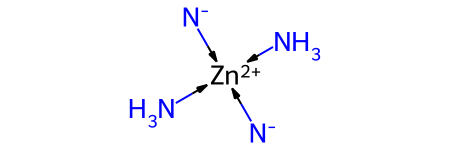

In [7]:
mol_1nn

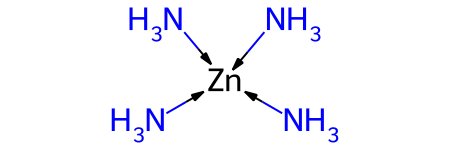

In [8]:
xyz_1nn

Clearly, the charges of TM centers and their coordination atoms are different, but the coordinating atoms and the numbers of coordinating atoms for molecules before and after optimization are the same.  
**Note**: since charges of ligands and coordinating atoms are decided by `xyz2mol_tmc`, it's not guaranteed that the charge assignments are identical before and after DFT optimization.

In [9]:
"""
    Compare 1st NN substructures of TM centers
    with charges and oxidation states
"""
full_match = identical_match(mol_1nn, xyz_1nn)
print('Identical:', full_match)

Identical: False


In [10]:
"""
    Compare molecular graphs without charges
"""
graph_match = compare_same_structure_different_charges(mol_1nn, xyz_1nn)
for k, v in graph_match.items():
    print(f'{k}:', v)

same_structure_ignoring_charges: True
same_charge_assignment_under_some_mapping: False
same_structure_but_different_charges: True
example_atom_mapping: [(1, 1), (0, 0), (2, 2), (4, 3), (3, 4)]
charge_differences: [(0, 0, 2, 0), (4, 3, -1, 0), (3, 4, -1, 0)]
mcs_smarts: [#7]->[#30](<-[#7])(<-[#7])<-[#7]


### 2. Compare isolated ligands
To compare the isolated ligands of TMC molecules before and after relaxation, we need to consider charges and atom connections. A fast method is to compare the canonical SMILES of each ligand. However, since the charge assignment may not be ideal and it will affect the canonical SMILES of TMCs, we need to compare the molecular graphs of ligands as a second approach.

In [11]:
"""
    Get ligand fragment lists
"""
## First, get the molecule without TM centers and dative coordination bonds
mol_ligs, mol_lig_coord, mol_atm_map = remove_tm(tmc_mol)
mol_fmol = set_coordinating_atoms(mol_ligs, mol_lig_coord)

## Then, separate isolated ligands and break the molecule into ligand fragments
mol_frags = [n[0] for n in molecule2frags_reindex(mol_fmol, warn=False)]


xyz_ligs, xyz_lig_coord, xyz_atm_map = remove_tm(xyz_mol)
xyz_fmol = set_coordinating_atoms(xyz_ligs, xyz_lig_coord)
xyz_frags = [n[0] for n in molecule2frags_reindex(xyz_fmol, warn=False)]

In [12]:
"""
    Using canonical SMILES strings to compare ligands
"""
ligand_list_results = compare_ligand_fragment_lists(mol_frags, xyz_frags, include_charges=False,
                                                    include_stereochemistry=False,
                                                    include_isotopes=False,
                                                    ignore_atom_map_numbers=True)
print('The same number of isolated ligands:', len(mol_frags)==len(xyz_frags))
for m, x in zip(mol_frags, xyz_frags):
    print(MolToSmiles(m, canonical=True), MolToSmiles(x, canonical=True))

The same number of isolated ligands: True
CCC1=C(C)c2cc3[n-]c(cc4nc(cc5[n-]c(cc1n2)c(CC)c5C)C(C)=C4CC)c(CC)c3CC CCC1=C(C)C2=NC1=CC1=NC(=CC3=NC(=CC4=NC(=C2)C(C)=C4CC)C(CC)=C3C)C(CC)=C1CC


In [13]:
for k, v in ligand_list_results.items():
    print(f'{k}:', v)

same_ligand_multiset: False
mapping_1_to_2: {}
mapping_2_to_1: {}
unmatched_1: [0]
unmatched_2: [0]
duplicate_fragment_identities: {}
fragment_keys_1: ['CCC1=C(C)C2=NC1=CC1=NC(=CC3=NC(=CC4=NC(=C2)C(C)=C4CC)C(CC)=C3CC)C(C)=C1CC']
fragment_keys_2: ['CCC1=C(C)C2=NC1=CC1=NC(=CC3=NC(=CC4=NC(=C2)C(C)=C4CC)C(CC)=C3C)C(CC)=C1CC']
reason: Ligand fragment multisets differ.


In [14]:
"""
    Compare the molecular graphs of ligands
"""
ligand_graph_results = compare_ligand_graph_lists(mol_frags, xyz_frags, include_charges=False,
                                                  include_stereochemistry=False,
                                                  include_isotopes=False,
                                                  ignore_atom_map_numbers=True)

In [15]:
for k, v in ligand_graph_results.items():
    print(f'{k}:', v)

same_ligand_graphs: False
same_ligand_multiset: False
mapping_1_to_2: {}
mapping_2_to_1: {}
unmatched_1: [0]
unmatched_2: [0]
candidate_matches_1_to_2: {0: []}
duplicate_fragment_identities: {'list1_duplicate_groups': [], 'list2_duplicate_groups': []}
match_matrix: [[False]]
graph_keys_1: [<rdkit.Chem.rdchem.Mol object at 0x1484278f90e0>]
graph_keys_2: [<rdkit.Chem.rdchem.Mol object at 0x14841cbc4b30>]
reason: Could not find a complete one-to-one ligand graph matching.


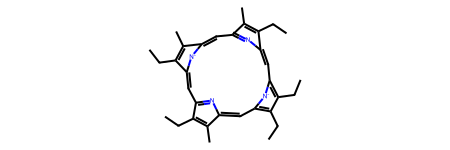

In [16]:
mol_frags[0]

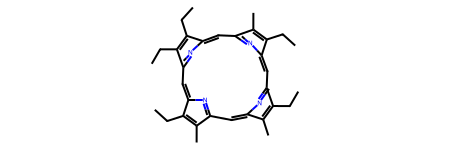

In [17]:
xyz_frags[0]

**Conclusion**:  
Clearly, the two isolated ligands have different bonds, which are affected by the charge assignment of ligands and TM center oxidation states.